# SARIMA Model

## Objective

This notebook develops a Seasonal Autoregressive Integrated Moving Average (SARIMA) model to forecast weekly German electricity demand.

The model parameters are selected using the Akaike Information Criterion (AIC). The fitted model is evaluated using residual diagnostics and forecasting accuracy metrics.

In [1]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

## Load Weekly Electricity Demand

The processed weekly electricity demand series is loaded and divided into training and testing datasets. The final two years (104 weeks) are reserved for forecast evaluation.

In [2]:
# Load weekly electricity demand

weekly_load = pd.read_csv(
    "https://raw.githubusercontent.com/dekshinaudayan/german-electricity-demand-forecasting/refs/heads/main/data/processed/weekly_load.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

weekly_load.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


## Train-Test Split

The weekly electricity demand dataset is divided into training and testing sets.

The final 104 weekly observations are reserved for evaluating the forecasting performance of the SARIMA model.

In [3]:
# Split into training and testing data

forecast_horizon = 104

train = weekly_load.iloc[:-forecast_horizon]

test = weekly_load.iloc[-forecast_horizon:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


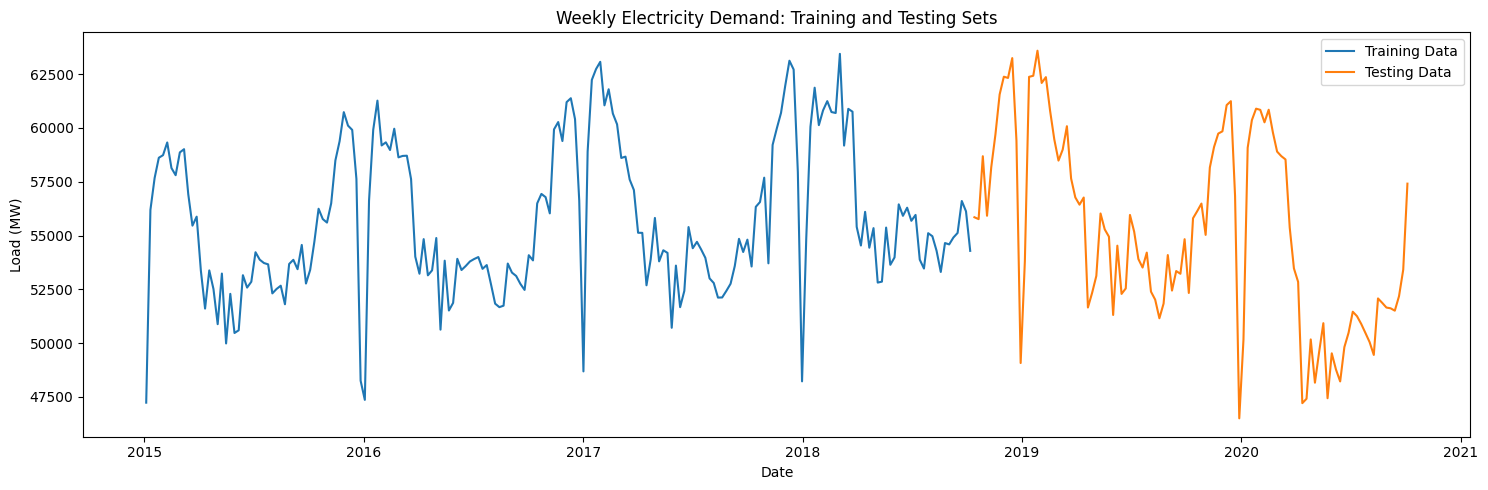

In [4]:
# Plot training and testing datasets

plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Testing Data"
)

plt.title("Weekly Electricity Demand: Training and Testing Sets")

plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "train_test_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Evaluation Function

The SARIMA model will be evaluated using the following performance metrics:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

These metrics will be used consistently across all forecasting models for comparison.

In [5]:
def evaluate_forecast(actual, forecast):

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

## SARIMA Model Selection

Several candidate SARIMA models were evaluated using the Akaike Information Criterion (AIC). The candidate models were selected based on insights from the stationarity analysis and ACF/PACF plots. The model with the lowest AIC value was selected for forecasting.

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

results = []

seasonal_order = (0, 1, 1, 52)

for p in range(7):
    for d in range(3):
        for q in range(7):

            try:

                model = SARIMAX(
                    train["load"],
                    order=(p, d, q),
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fitted_model = model.fit(disp=False)

                results.append({
                    "ARIMA": (p, d, q),
                    "Seasonal": seasonal_order,
                    "AIC": fitted_model.aic
                })

                print(
                    f"ARIMA({p},{d},{q}) "
                    f"AIC = {fitted_model.aic:.2f}"
                )

            except:
                continue

ARIMA(0,0,0) AIC = 1643.60
ARIMA(0,0,1) AIC = 1609.77
ARIMA(0,0,2) AIC = 1588.47
ARIMA(0,0,3) AIC = 1568.74
ARIMA(0,0,4) AIC = 1547.61
ARIMA(0,0,5) AIC = 1530.19
ARIMA(0,0,6) AIC = 1514.52
ARIMA(0,1,0) AIC = 1622.33
ARIMA(0,1,1) AIC = 1582.04
ARIMA(0,1,2) AIC = 1558.25
ARIMA(0,1,3) AIC = 1539.54
ARIMA(0,1,4) AIC = 1523.47
ARIMA(0,1,5) AIC = 1508.20
ARIMA(0,1,6) AIC = 1485.18
ARIMA(0,2,0) AIC = 1686.04
ARIMA(0,2,1) AIC = 1603.48
ARIMA(0,2,2) AIC = 1549.65
ARIMA(0,2,3) AIC = 1544.51
ARIMA(0,2,4) AIC = 1520.53
ARIMA(0,2,5) AIC = 1502.76
ARIMA(0,2,6) AIC = 1486.16
ARIMA(1,0,0) AIC = 1618.21
ARIMA(1,0,1) AIC = 1597.39
ARIMA(1,0,2) AIC = 1580.10
ARIMA(1,0,3) AIC = 1564.53
ARIMA(1,0,4) AIC = 1545.57
ARIMA(1,0,5) AIC = 1528.00
ARIMA(1,0,6) AIC = 1508.33
ARIMA(1,1,0) AIC = 1610.77
ARIMA(1,1,1) AIC = 1578.41
ARIMA(1,1,2) AIC = 1562.59
ARIMA(1,1,3) AIC = 1544.91
ARIMA(1,1,4) AIC = 1527.45
ARIMA(1,1,5) AIC = 1509.53
ARIMA(1,1,6) AIC = 1489.65
ARIMA(1,2,0) AIC = 1656.24
ARIMA(1,2,1) AIC = 1593.60
A

In [7]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("AIC")

display(results_df.head(10))

,ARIMA,Seasonal,AIC
62,"(2, 2, 6)","(0, 1, 1, 52)",1479.741752
83,"(3, 2, 6)","(0, 1, 1, 52)",1481.168570
41,"(1, 2, 6)","(0, 1, 1, 52)",1482.480259
104,"(4, 2, 6)","(0, 1, 1, 52)",1482.934017
125,"(5, 2, 6)","(0, 1, 1, 52)",1484.433623
13,"(0, 1, 6)","(0, 1, 1, 52)",1485.184646
146,"(6, 2, 6)","(0, 1, 1, 52)",1485.481826
20,"(0, 2, 6)","(0, 1, 1, 52)",1486.158156
34,"(1, 1, 6)","(0, 1, 1, 52)",1489.648712
55,"(2, 1, 6)","(0, 1, 1, 52)",1491.592530


In [8]:
best_order = results_df.iloc[0]["ARIMA"]

best_seasonal = results_df.iloc[0]["Seasonal"]

print("Best ARIMA Order:", best_order)

print("Best Seasonal Order:", best_seasonal)

Best ARIMA Order: (2, 2, 6)
Best Seasonal Order: (0, 1, 1, 52)


## Final SARIMA Model

Based on the AIC comparison, the SARIMA(1,1,2)(0,1,1,52) model was selected as the final forecasting model. The model was fitted using the training dataset before generating forecasts for the testing period.

In [20]:
sarima_model = SARIMAX(
    train["load"],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)

print(sarima_results.summary())

results_df.to_csv(
    "sarima_model_selection.csv",
    index=False
)

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(2, 2, 6)x(0, 1, [1], 52)   Log Likelihood                -729.871
Date:                              Thu, 16 Jul 2026   AIC                           1479.742
Time:                                      10:44:49   BIC                           1504.050
Sample:                                  01-04-2015   HQIC                          1489.513
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0327      0.069    -14.915      0.000      -1.168      -0.897
ar.L2         -0.96

## Residual Diagnostics

Residual diagnostics were performed to evaluate the adequacy of the fitted SARIMA model. The residuals were inspected visually to assess whether they resembled white noise.

In [10]:
# Extract model residuals

residuals = sarima_results.resid

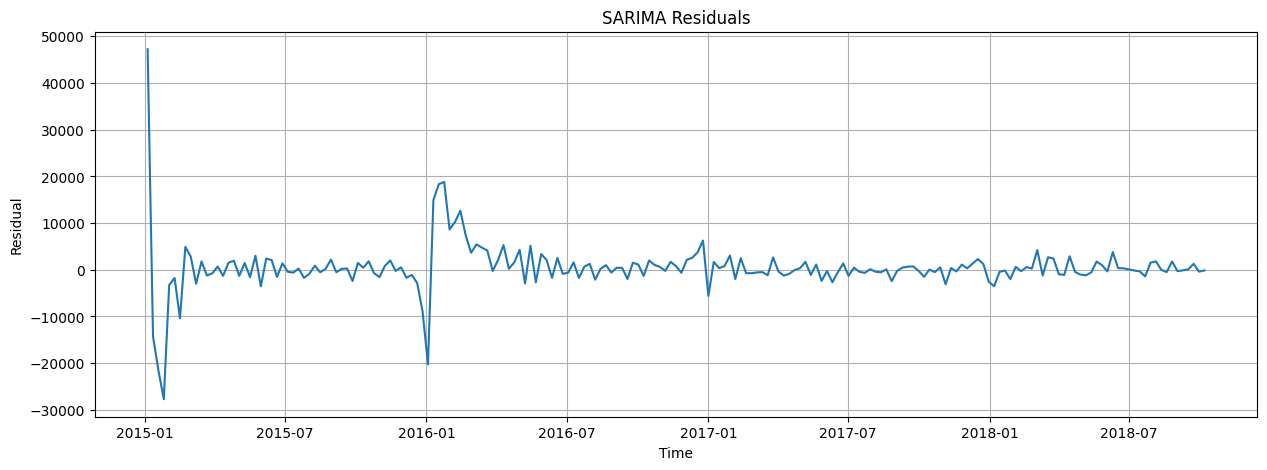

In [11]:
plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("SARIMA Residuals")

plt.xlabel("Time")

plt.ylabel("Residual")

plt.grid(True)

plt.savefig(
    "sarima_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

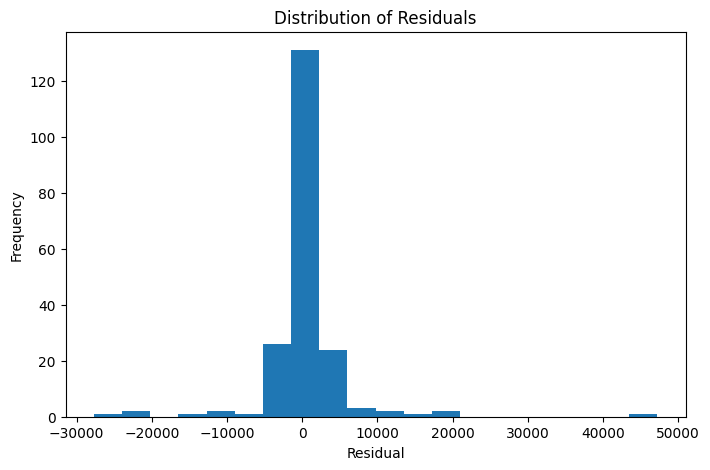

In [12]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=20)

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.savefig(
    "sarima_residual_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

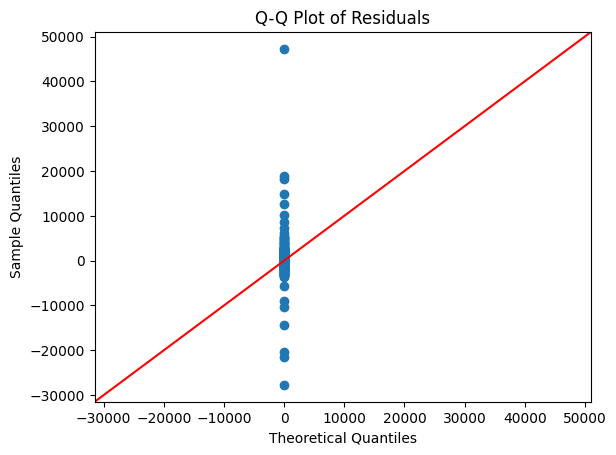

In [13]:
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line="45")

plt.title("Q-Q Plot of Residuals")

plt.savefig(
    "sarima_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
10  13.794748   0.182561


## SARIMA Forecasting

The fitted SARIMA model was used to generate forecasts for the testing period. Forecast performance was evaluated by comparing the predicted values with the observed weekly electricity demand.

In [15]:
# Generate forecasts for the testing period

sarima_forecast = sarima_results.get_forecast(
    steps=len(test)
)

forecast_mean = sarima_forecast.predicted_mean

forecast_ci = sarima_forecast.conf_int()

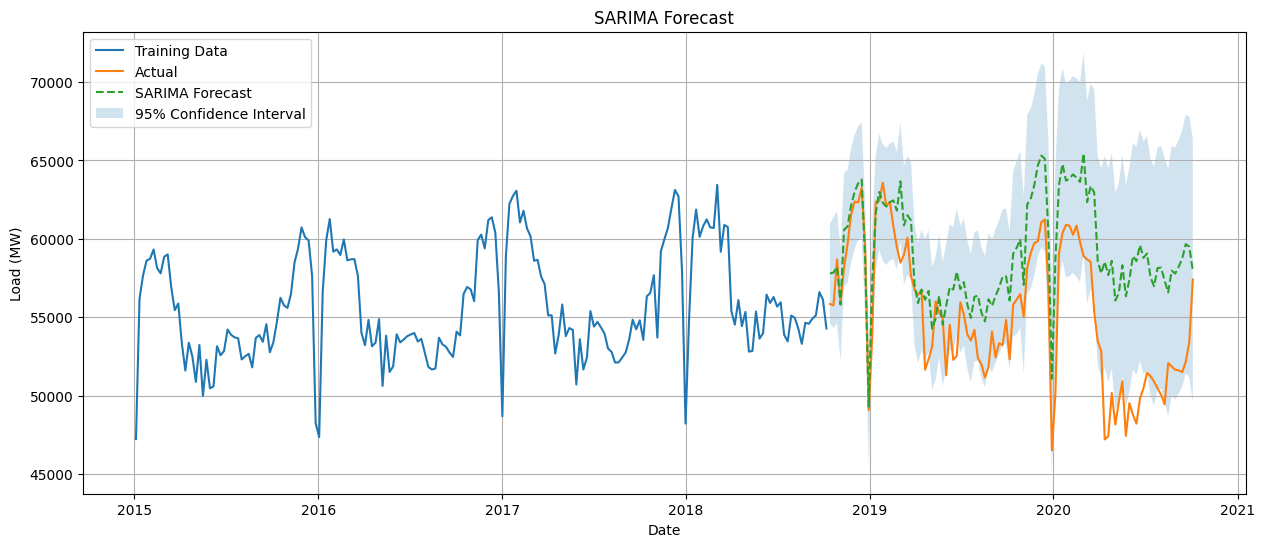

In [16]:
plt.figure(figsize=(15,6))

# Training data
plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

# Actual values
plt.plot(
    test.index,
    test["load"],
    label="Actual"
)

# Forecast
plt.plot(
    test.index,
    forecast_mean,
    linestyle="--",
    label="SARIMA Forecast"
)

# Confidence interval
plt.fill_between(
    test.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Load (MW)")

plt.legend()

plt.grid(True)

plt.savefig(
    "sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
sarima_metrics = evaluate_forecast(
    test["load"],
    forecast_mean
)

print(sarima_metrics)

{'RMSE': np.float64(4869.959973177466), 'MAE': 3988.4150671243456, 'MAPE': np.float64(7.557674495997786)}


In [18]:
sarima_metrics_df = pd.DataFrame([sarima_metrics])

sarima_metrics_df.to_csv(
    "sarima_metrics.csv",
    index=False
)

sarima_metrics_df

,RMSE,MAE,MAPE
0,4869.959973,3988.415067,7.557674


In [19]:
forecast_df = pd.DataFrame({
    "Actual": test["load"],
    "Forecast": forecast_mean
})

forecast_df.to_csv(
    "sarima_forecast.csv",
    index=True
)

forecast_df.head()

,Actual,Forecast
2018-10-14 00:00:00+00:00,55848.940476,57793.499717
2018-10-21 00:00:00+00:00,55762.125000,57851.827119
2018-10-28 00:00:00+00:00,58684.714286,58206.852714
2018-11-04 00:00:00+00:00,55917.589286,55807.355348
2018-11-11 00:00:00+00:00,58163.470238,60573.737466
